In [1]:
import xarray as xr
import numpy as np

# masks have been applied in 
# apply_ice_and_land_mask_to_JRA_outputs.ipynb
# apply_ice_and_land_mask_to_ERA_outputs.ipynb


In [2]:
%%time 

YEAR_START = 1959
YEAR_FIN = 2019

out_var_type = 'ocn'
with_ice_mask = True

PATH = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/MONTHLY/"
PATH_OUT = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/YEARLY/"

PATH_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_1990_1999/cpl/hist/'
filename_raw = 'a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_1990_1999.cpl.hi.2000-01-01-00000.nc'

# area_raw = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['MED_ocn_area'].isel(time=0)
# R2 = 6371e3**2
# area = (area_raw*R2).rename({"MED_ocn_ny": "y", "MED_ocn_nx": "x"})

lat_raw = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['ocnExp_lat'].isel(time=0, drop = True).rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})


land_mask = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
# land_mask = land_mask.where(land_mask != 0, np.nan)

weights = np.cos(np.deg2rad(lat_raw))*land_mask
weights = weights / weights.sum()  # Normalize so they sum to 1


if out_var_type == 'ocn':
    variables = {
        "latent": "ocnExp_Foxx_lat",
        "sensible": "ocnExp_Foxx_sen",
        "swnet": "ocnExp_Foxx_swnet",
        "lwnet": "ocnExp_Foxx_lwnet"
    }
elif out_var_type == 'atm':
    variables = {
        "atm_swnet": "atmImp_Faxa_swnet"
    }

yearly_data = {}

for var_type, var_name in variables.items():
    if var_type not in yearly_data:
        yearly_data[var_type] = []

    for YEAR in range(YEAR_START, YEAR_FIN+1):  
        if YEAR % 5 == 0:
            print(var_type + ': ' + str(YEAR))
        if with_ice_mask:
            model_file = f"{PATH}{YEAR}.{var_type}.monthly_ice_mask.nc"
            model_ds = xr.open_dataset(model_file)
        else:
            model_file = f"{PATH}{YEAR}.{var_type}.monthly.nc"
            if out_var_type == 'ocn':
                model_ds = xr.open_dataset(model_file).rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
            else:
                model_ds = xr.open_dataset(model_file).rename({"atmImp_ny": "y", "atmImp_nx": "x"})
        model_var = model_ds[var_name].fillna(0)
        # ice_land_mask = xr.where(model_var == 0, np.nan, 1)

        # weights = (land_mask * area)/(land_mask * area).sum(dim=("y", "x"))
        # weights = weights.fillna(0)

        weights = np.cos(np.deg2rad(lat_raw))*land_mask
        weights = weights / weights.sum()  # Normalize so they sum to 1
        weights_br = weights.broadcast_like(model_ds[var_name])

        var_time_series = model_var.weighted(weights_br).mean(dim=["x", "y"])

        yearly_data[var_type].append(var_time_series.mean('time').values)
        
        del(weights_br)
    # print(kkk)

year_range = np.arange(YEAR_START, YEAR_FIN + 1)

yearly_ds = xr.Dataset(
        {var_type: (["time"], yearly_data[var_type]) for var_type in variables.keys()},
        coords={"time": year_range}
    )

latent: 1960
latent: 1965
latent: 1970
latent: 1975
latent: 1980
latent: 1985
latent: 1990
latent: 1995
latent: 2000
latent: 2005
latent: 2010
latent: 2015
sensible: 1960
sensible: 1965
sensible: 1970
sensible: 1975
sensible: 1980
sensible: 1985
sensible: 1990
sensible: 1995
sensible: 2000
sensible: 2005
sensible: 2010
sensible: 2015
swnet: 1960
swnet: 1965
swnet: 1970
swnet: 1975
swnet: 1980
swnet: 1985
swnet: 1990
swnet: 1995
swnet: 2000
swnet: 2005
swnet: 2010
swnet: 2015
lwnet: 1960
lwnet: 1965
lwnet: 1970
lwnet: 1975
lwnet: 1980
lwnet: 1985
lwnet: 1990
lwnet: 1995
lwnet: 2000
lwnet: 2005
lwnet: 2010
lwnet: 2015
CPU times: user 24 s, sys: 15.8 s, total: 39.8 s
Wall time: 1min 35s


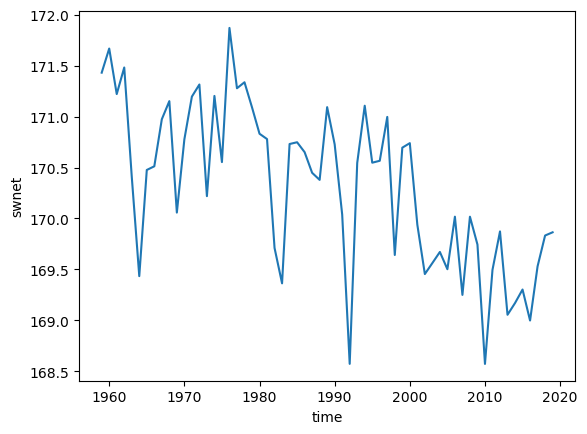

In [4]:
yearly_ds.swnet.plot()

In [5]:
if with_ice_mask:
    output_file = f"{PATH_OUT}{YEAR_START}_{YEAR_FIN}_{out_var_type}_yearly_weighted_means_with_ice_mask.nc"
else:
    output_file = f"{PATH_OUT}{YEAR_START}_{YEAR_FIN}_{out_var_type}_yearly_weighted_means_no_ice_mask.nc"
yearly_ds.to_netcdf(output_file)

print(f"Yearly time series saved to {output_file}")

Yearly time series saved to /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/YEARLY/1959_2019_ocn_yearly_weighted_means_with_ice_mask.nc
